Step 1: Load Data and Basic Inspection

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('../data/processed/dataset.csv')

# Basic info
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nFirst 5 rows:")
df.head()

Shape: (9389, 23)

Columns:
['stop_id', 'route_id', 'route_short_name', 'trip_id', 'vehicle_id', 'snapshot_ts', 'gtfs_scheduled_ts', 'predicted_arrival_ts', 'delay_min', 'hour_of_day', 'day_of_week', 'is_weekend', 'is_peak_hour', 'month', 'date', 'hour_bucket', 'status', 'temperature_c', 'precipitation_mm', 'wind_speed_kmh', 'visibility_km', 'weather_code', 'is_raining']

Data types:
stop_id                  object
route_id                 object
route_short_name         object
trip_id                  object
vehicle_id               object
snapshot_ts               int64
gtfs_scheduled_ts       float64
predicted_arrival_ts      int64
delay_min               float64
hour_of_day             float64
day_of_week             float64
is_weekend                int64
is_peak_hour              int64
month                   float64
date                     object
hour_bucket              object
status                   object
temperature_c           float64
precipitation_mm        float64
wind_

,stop_id,route_id,route_short_name,trip_id,vehicle_id,snapshot_ts,gtfs_scheduled_ts,predicted_arrival_ts,delay_min,hour_of_day,...,month,date,hour_bucket,status,temperature_c,precipitation_mm,wind_speed_kmh,visibility_km,weather_code,is_raining
0,1_103,1_102745,G Line,1_736436399,1_6410,1772857541,1.772857e+09,1772857575,5.92,20.0,...,3.0,2026-03-06,2026-03-06 20:00,default,9.6,0.3,21.2,NaN,51,1
1,1_85800,1_100196,331,1_778705889,1_7203,1772857541,1.772857e+09,1772857599,5.78,20.0,...,3.0,2026-03-06,2026-03-06 20:00,default,9.6,0.3,21.2,NaN,51,1
2,1_2850,1_100089,2,1_768042249,1_7975173,1772896231,1.772896e+09,1772896380,-2.48,7.0,...,3.0,2026-03-07,2026-03-07 07:00,default,9.8,0.0,16.6,NaN,3,0
3,1_2850,1_100089,2,1_768040879,1_7134,1772896231,1.772897e+09,1772897220,-16.48,7.0,...,3.0,2026-03-07,2026-03-07 07:00,default,9.8,0.0,16.6,NaN,3,0
4,1_45920,1_100031,132,1_759744689,1_8013,1772896231,1.772896e+09,1772896269,-2.25,7.0,...,3.0,2026-03-07,2026-03-07 07:00,default,9.8,0.0,16.6,NaN,3,0


In [4]:
# Drop visibility_km (all null) and columns not useful for modeling
df = df.drop(columns=[
    'visibility_km',      # all null
    'snapshot_ts',        # timestamp, used to compute delay_min
    'gtfs_scheduled_ts',  # timestamp, used to compute delay_min
    'predicted_arrival_ts', # timestamp, used to compute delay_min
    'trip_id',            # unique identifier, no predictive value
    'vehicle_id',         # unique identifier, no predictive value
    'status',             # all 'default', no variation
    'date',               # already captured by other time features
    'hour_bucket',        # already captured by hour_of_day
    'month',              # only one month in dataset
])

print("Shape after dropping columns:", df.shape)
print("Remaining columns:", df.columns.tolist())

Shape after dropping columns: (9389, 13)
Remaining columns: ['stop_id', 'route_id', 'route_short_name', 'delay_min', 'hour_of_day', 'day_of_week', 'is_weekend', 'is_peak_hour', 'temperature_c', 'precipitation_mm', 'wind_speed_kmh', 'weather_code', 'is_raining']


Step 2: Target Variable Analysis

=== delay_min Statistics ===
count    9389.000000
mean       -3.882150
std         7.785721
min       -29.980000
25%        -5.330000
50%        -2.150000
75%         0.120000
max        40.550000
Name: delay_min, dtype: float64

Mean delay:   -3.88 min
Median delay: -2.15 min
% early (< 0): 74.3%
% on time (0-2 min): 11.5%
% late (> 2 min): 14.1%


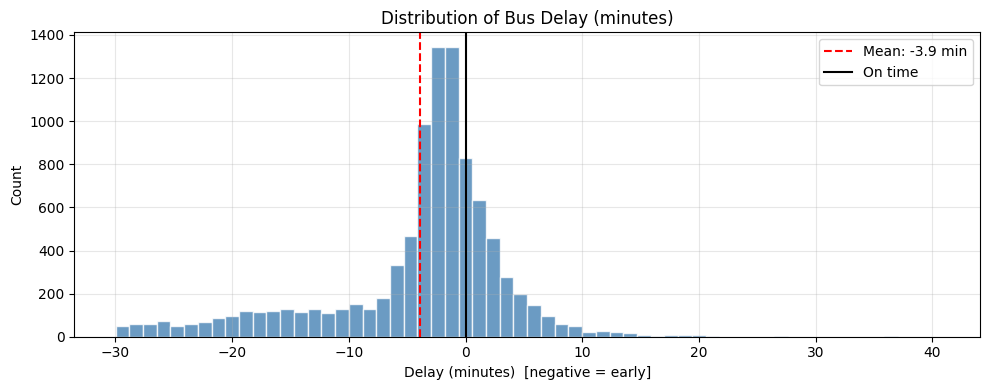

In [5]:
# Step 2: Target Variable Analysis — delay_min
print("=== delay_min Statistics ===")
print(df['delay_min'].describe())
print(f"\nMean delay:   {df['delay_min'].mean():.2f} min")
print(f"Median delay: {df['delay_min'].median():.2f} min")
print(f"% early (< 0): {(df['delay_min'] < 0).mean()*100:.1f}%")
print(f"% on time (0-2 min): {((df['delay_min'] >= 0) & (df['delay_min'] <= 2)).mean()*100:.1f}%")
print(f"% late (> 2 min): {(df['delay_min'] > 2).mean()*100:.1f}%")

# Plot distribution
plt.figure(figsize=(10, 4))
plt.hist(df['delay_min'], bins=60, color='steelblue', edgecolor='white', alpha=0.8)
plt.axvline(df['delay_min'].mean(), color='red', linestyle='--', label=f'Mean: {df["delay_min"].mean():.1f} min')
plt.axvline(0, color='black', linestyle='-', linewidth=1.5, label='On time')
plt.title('Distribution of Bus Delay (minutes)')
plt.xlabel('Delay (minutes)  [negative = early]')
plt.ylabel('Count')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Step 3: Core Question — Impact of Rain on Bus Delay

=== Rain vs No Rain ===
Rainy days   — count: 3447, mean: -3.59 min, median: -1.95 min
Non-rainy    — count: 5942, mean: -4.05 min, median: -2.32 min
Difference in mean: 0.46 min


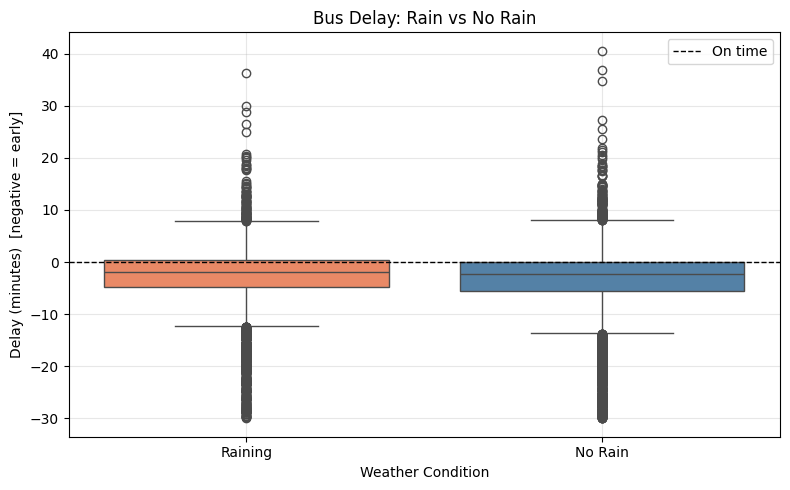

In [7]:
# Step 3: Rain vs No Rain delay comparison

# Numbers first
rain_delay = df[df['is_raining']==1]['delay_min']
no_rain_delay = df[df['is_raining']==0]['delay_min']

print("=== Rain vs No Rain ===")
print(f"Rainy days   — count: {len(rain_delay)}, mean: {rain_delay.mean():.2f} min, median: {rain_delay.median():.2f} min")
print(f"Non-rainy    — count: {len(no_rain_delay)}, mean: {no_rain_delay.mean():.2f} min, median: {no_rain_delay.median():.2f} min")
print(f"Difference in mean: {rain_delay.mean() - no_rain_delay.mean():.2f} min")

# Boxplot
plt.figure(figsize=(8, 5))
df['rain_label'] = df['is_raining'].map({0: 'No Rain', 1: 'Raining'})
sns.boxplot(data=df, x='rain_label', y='delay_min', hue='rain_label',
            palette={'No Rain': 'steelblue', 'Raining': 'coral'}, legend=False)
plt.axhline(0, color='black', linestyle='--', linewidth=1, label='On time')
plt.title('Bus Delay: Rain vs No Rain')
plt.xlabel('Weather Condition')
plt.ylabel('Delay (minutes)  [negative = early]')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Step 4: Time Feature Analysis

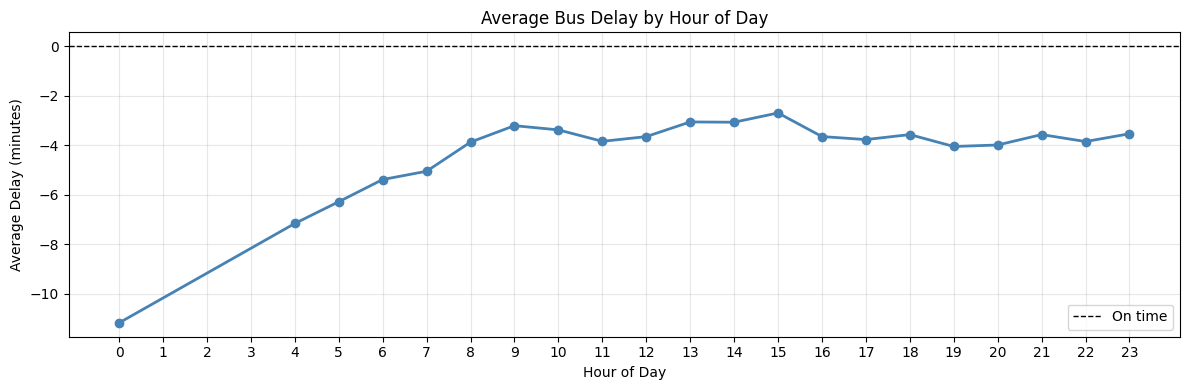

In [9]:
# Step 4: Time Feature Analysis

# Figure 1: Average delay by hour of day
plt.figure(figsize=(12, 4))
hourly_delay = df.groupby('hour_of_day')['delay_min'].mean()
plt.plot(hourly_delay.index, hourly_delay.values, 'o-', color='steelblue', linewidth=2)
plt.axhline(0, color='black', linestyle='--', linewidth=1, label='On time')
plt.title('Average Bus Delay by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Delay (minutes)')
plt.xticks(range(0, 24))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

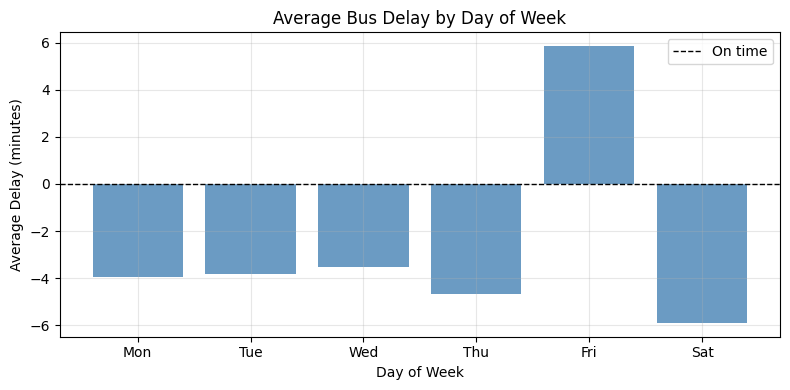

In [10]:
# Figure 2: Average delay by day of week
plt.figure(figsize=(8, 4))
day_labels = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}
daily_delay = df.groupby('day_of_week')['delay_min'].mean()
daily_delay.index = [day_labels[d] for d in daily_delay.index]
plt.bar(daily_delay.index, daily_delay.values, color='steelblue', alpha=0.8)
plt.axhline(0, color='black', linestyle='--', linewidth=1, label='On time')
plt.title('Average Bus Delay by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Delay (minutes)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
print(df['day_of_week'].value_counts().sort_index())

day_of_week
0.0    2976
1.0    2792
2.0    2725
3.0     778
4.0       2
5.0     116
Name: count, dtype: int64


Step 5: Correlation Analysis

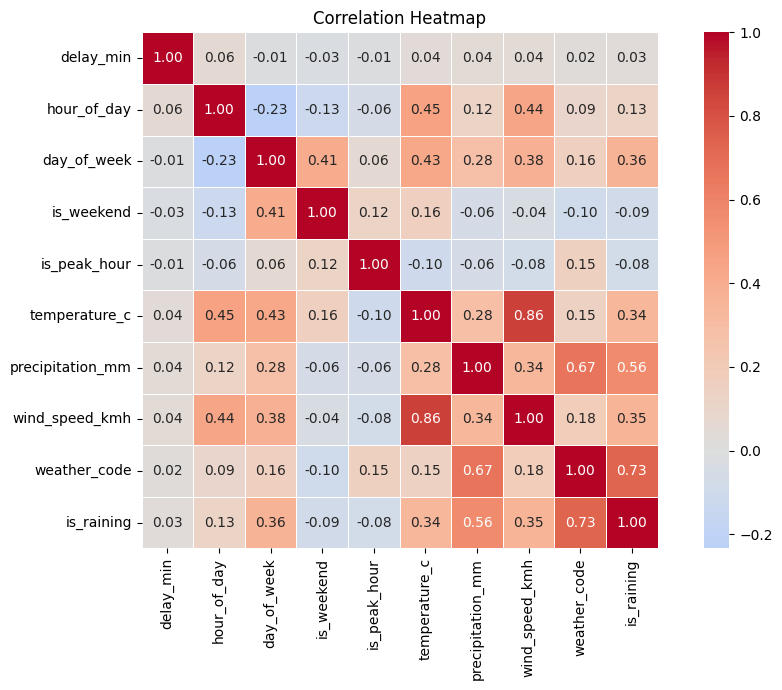

=== Correlation with delay_min ===
delay_min           1.000000
hour_of_day         0.061732
precipitation_mm    0.044482
wind_speed_kmh      0.042215
temperature_c       0.037731
is_raining          0.028430
weather_code        0.023868
is_peak_hour       -0.010733
day_of_week        -0.011273
is_weekend         -0.028978
Name: delay_min, dtype: float64


In [13]:
# Step 5: Correlation Analysis
plt.figure(figsize=(10, 7))

# Select only numeric columns
numeric_cols = ['delay_min', 'hour_of_day', 'day_of_week', 'is_weekend', 
                'is_peak_hour', 'temperature_c', 'precipitation_mm', 
                'wind_speed_kmh', 'weather_code', 'is_raining']

corr = df[numeric_cols].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

# Print correlation with target variable specifically
print("=== Correlation with delay_min ===")
print(corr['delay_min'].sort_values(ascending=False))

Step 6: Summary

In [14]:
# Step 6: Summary
print("""
=== EDA Summary ===

1. Dataset Overview:
   - 9,389 records collected from March 6-12, 2026
   - 13 features after dropping irrelevant columns
   - No missing values except visibility_km (dropped)

2. Target Variable (delay_min):
   - Most buses arrive EARLY (74.3% early, 14.1% late)
   - Average delay: -3.88 min (early), median: -2.15 min
   - Range: -30 min (very early) to +40 min (very late)

3. Rain Impact (Core Question):
   - Rainy mean delay:    -3.59 min
   - Non-rainy mean delay: -4.05 min
   - Difference: only 0.46 min
   - Conclusion: Rain has minimal impact on bus delay

4. Time Patterns:
   - Late night (hour 0): most early (-11 min), less traffic
   - Daytime (hour 9+): stable around -3 to -4 min
   - Friday only has 2 records — not representative
   - Sunday: no data collected

5. Correlation with delay_min:
   - All features show very low correlation (< 0.07)
   - hour_of_day is the strongest predictor (0.06)
   - Linear regression may have low R-squared
   - weather_code and is_raining are redundant (0.73)
   - temperature_c and wind_speed_kmh are redundant (0.86)

6. Implications for Modeling:
   - Keep: hour_of_day, is_weekend, is_peak_hour,
           temperature_c, precipitation_mm, is_raining
   - Drop redundant: weather_code, wind_speed_kmh
   - Expect low R-squared due to weak correlations
""")


=== EDA Summary ===

1. Dataset Overview:
   - 9,389 records collected from March 6-12, 2026
   - 13 features after dropping irrelevant columns
   - No missing values except visibility_km (dropped)

2. Target Variable (delay_min):
   - Most buses arrive EARLY (74.3% early, 14.1% late)
   - Average delay: -3.88 min (early), median: -2.15 min
   - Range: -30 min (very early) to +40 min (very late)

3. Rain Impact (Core Question):
   - Rainy mean delay:    -3.59 min
   - Non-rainy mean delay: -4.05 min
   - Difference: only 0.46 min
   - Conclusion: Rain has minimal impact on bus delay

4. Time Patterns:
   - Late night (hour 0): most early (-11 min), less traffic
   - Daytime (hour 9+): stable around -3 to -4 min
   - Friday only has 2 records — not representative
   - Sunday: no data collected

5. Correlation with delay_min:
   - All features show very low correlation (< 0.07)
   - hour_of_day is the strongest predictor (0.06)
   - Linear regression may have low R-squared
   - weather_